
# Shot-Make Prediction (2013–14): Distance vs Proxy — with Accuracy & Threshold Sweep

This notebook compares **two ways to estimate shot difficulty** when predicting if a shot will go in:

- **Distance model**: uses the *true* `defender_distance` (how far the nearest defender was).
- **Proxy model**: uses enriched features (e.g., `SHOT_CLOCK_APPROX`, `contest_score`, `contest_label`, `contest_reasons`) that **approximate defensive pressure** and clock pressure when tracking data isn’t available.

We train both models with **5-fold cross-validation** and evaluate with:
- **AUC**: How well the model separates makes vs misses (higher is better).
- **Log Loss**: How accurate the probabilities are (lower is better).
- **Brier Score**: How well probabilities are calibrated (lower is better).
- **Accuracy** (at a default 0.5 threshold): Easy-to-read percent correct.

Finally, we **sweep classification thresholds** to see whether 0.5 is optimal, and end with a **story‑like summary** of what the results mean on the court.



## 1) Imports & Setup

We’ll use:  
- **pandas / numpy** for data wrangling  
- **scikit‑learn** for preprocessing, cross‑validation, modeling, and metrics  
- **matplotlib** for plots

Set `DATA_PATH` to your enriched 2013–14 dataset.


In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Update this if your path differs
DATA_PATH = "enriched_data/nba_savant_2014_enriched_shots_v2.csv"
RANDOM_STATE = 42

def banner(msg):
    print("\n" + "="*len(msg))
    print(msg)
    print("="*len(msg))



## 2) Load the Enriched Data

We load the enriched Savant file for **2013–14**.  
These files add proxy contest features to compensate for missing tracking (defender distance, shot clock).

In [2]:

banner("Load enriched data")
assert os.path.exists(DATA_PATH), f"Missing file: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns (first 30):", list(df.columns)[:30], "...")
df.head()



Load enriched data
Shape: (205550, 29)
Columns (first 30): ['name', 'team_name', 'game_date', 'season', 'espn_player_id', 'team_id', 'espn_game_id', 'period', 'minutes_remaining', 'seconds_remaining', 'shot_made_flag', 'action_type', 'shot_type', 'shot_distance', 'opponent', 'x', 'y', 'dribbles', 'touch_time', 'defender_name', 'defender_distance', 'shot_clock', 'team', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'contest_score', 'contest_label', 'contest_reasons', 'shotValue'] ...


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,Kevin Love,Cleveland Cavaliers,2014-10-31,2014,3449.0,1610612739,400578314.0,3,3,20,...,"Dunleavy, Mike",1.3,11.8,CLE,11.8,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Timofey Mozgov,Cleveland Cavaliers,2015-04-10,2014,4298.0,1610612739,400579470.0,1,4,50,...,"Zeller, Tyler",3.7,11.0,CLE,11.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tristan Thompson,Cleveland Cavaliers,2014-11-29,2014,6474.0,1610612739,400578530.0,3,11,11,...,"Sloan, Donald",0.5,14.9,CLE,14.9,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
3,Tristan Thompson,Cleveland Cavaliers,2015-01-30,2014,6474.0,1610612739,400578992.0,2,0,2,...,"Cousins, DeMarcus",2.6,0.0,CLE,0.0,from_savant_shot_clock,2,likely_contested,"location: at-rim/very close, clock: late-clock...",2
4,LeBron James,Cleveland Cavaliers,2014-12-21,2014,1966.0,1610612739,400578693.0,4,10,11,...,"Pondexter, Quincy",5.4,19.0,CLE,19.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2



## 3) Light Cleaning & Target Definition

We coerce numeric columns, fill categorical NAs with `"Unknown"`, and define the **target** `shot_made_flag` (1 if made, 0 if missed).  
We also compute `shot_points` (2 or 3) for future analyses.


In [3]:

banner("Basic cleaning & target")

expected_cols = [
    "shot_made_flag", "shot_type", "shot_distance", "period",
    "minutes_remaining", "seconds_remaining", "x", "y",
    "dribbles", "touch_time", "defender_distance",
    "SHOT_CLOCK_APPROX", "contest_score", "contest_label", "contest_reasons",
    "team_name", "opponent", "name"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    print("Note: missing expected columns:", missing)

num_candidates = ["shot_made_flag","shot_distance","period","minutes_remaining","seconds_remaining",
                  "x","y","dribbles","touch_time","defender_distance","SHOT_CLOCK_APPROX","contest_score"]
for c in num_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "shot_made_flag" in df.columns:
    df["shot_made_flag"] = df["shot_made_flag"].fillna(0).astype(int)

for c in ["contest_label","contest_reasons","shot_type","team_name","opponent","name"]:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

if "shot_type" in df.columns:
    df["shot_points"] = np.where(df["shot_type"].astype(str).str.contains("3PT"), 3, 2).astype(int)

y = df["shot_made_flag"].values
print("Positive rate (makes):", y.mean().round(4))



Basic cleaning & target
Positive rate (makes): 0.4489



## 4) Define Feature Sets (Distance vs Proxy)

We build **two** feature sets that both include **common shot context**:  
`shot_distance`, `period`, `minutes_remaining`, `seconds_remaining`, `x`, `y`, `dribbles`, `touch_time`.

- **Distance model** adds `defender_distance` (if present).  
- **Proxy model** adds `SHOT_CLOCK_APPROX`, `contest_score` (numeric) and one‑hot encodes `contest_label`, `contest_reasons` (categorical).


In [4]:

banner("Define feature sets")

base_num = [c for c in [
    "shot_distance","period","minutes_remaining","seconds_remaining",
    "x","y","dribbles","touch_time"
] if c in df.columns]

distance_num = base_num + (["defender_distance"] if "defender_distance" in df.columns else [])

proxy_num = base_num + (
    ["SHOT_CLOCK_APPROX","contest_score"]
    if ("SHOT_CLOCK_APPROX" in df.columns and "contest_score" in df.columns)
    else []
)
proxy_cat = [c for c in ["contest_label","contest_reasons"] if c in df.columns]

print("Base numeric:", base_num)
print("Distance numeric:", distance_num)
print("Proxy numeric:", proxy_num, "| Proxy categorical:", proxy_cat)



Define feature sets
Base numeric: ['shot_distance', 'period', 'minutes_remaining', 'seconds_remaining', 'x', 'y', 'dribbles', 'touch_time']
Distance numeric: ['shot_distance', 'period', 'minutes_remaining', 'seconds_remaining', 'x', 'y', 'dribbles', 'touch_time', 'defender_distance']
Proxy numeric: ['shot_distance', 'period', 'minutes_remaining', 'seconds_remaining', 'x', 'y', 'dribbles', 'touch_time', 'SHOT_CLOCK_APPROX', 'contest_score'] | Proxy categorical: ['contest_label', 'contest_reasons']



## 5) Helper: Out‑of‑Fold Predictions (Fair Evaluation)

`get_oof_predictions()` does 5‑fold Stratified CV and returns:  
- **OOF probabilities** for every shot (out‑of‑sample),  
- the fitted **fold models**, and  
- which **columns** were used.

We scale numeric features and one‑hot encode categoricals inside a `Pipeline` so the process is reproducible.


In [5]:

def get_oof_predictions(X_df, y, num_cols, cat_cols=None, model_type="gb", n_splits=5, random_state=42):
    cat_cols = cat_cols or []
    use_cols = [c for c in num_cols if c in X_df.columns] + [c for c in cat_cols if c in X_df.columns]
    X = X_df[use_cols].copy()

    transformers = []
    if num_cols:
        transformers.append(("num", StandardScaler(with_mean=False), [c for c in num_cols if c in X.columns]))
    if cat_cols:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", drop=None), [c for c in cat_cols if c in X.columns]))

    pre = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)

    clf = GradientBoostingClassifier(random_state=random_state) if model_type=="gb" else LogisticRegression(max_iter=1000)
    pipe = Pipeline([("pre", pre), ("clf", clf)])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros(len(X))
    models = []
    for tr, va in skf.split(X, y):
        pipe.fit(X.iloc[tr], y[tr])
        oof[va] = pipe.predict_proba(X.iloc[va])[:, 1]
        models.append(pipe)

    return oof, models, use_cols



## 6) Train & Evaluate (AUC / LogLoss / Brier / Accuracy)

We train the **Distance** and **Proxy** setups, compute **OOF probabilities**, and evaluate four metrics.  
Accuracy is computed at the standard **0.5** decision threshold.


In [6]:

banner("Run CV comparisons: GradientBoostingClassifier")
setups = {}

# Distance
if len(distance_num) > 0:
    oof_dist, models_dist, cols_dist = get_oof_predictions(df, y, distance_num, [], model_type="gb", random_state=RANDOM_STATE)
    setups["distance"] = dict(oof=oof_dist, models=models_dist, cols=cols_dist)
else:
    print("Distance setup skipped (no defender_distance).")

# Proxy
if len(proxy_num) > 0 or len(proxy_cat) > 0:
    oof_proxy, models_proxy, cols_proxy = get_oof_predictions(df, y, proxy_num, proxy_cat, model_type="gb", random_state=RANDOM_STATE)
    setups["proxy"] = dict(oof=oof_proxy, models=models_proxy, cols=cols_proxy)
else:
    print("Proxy setup skipped (missing proxy cols).")

rows = []
for name, s in setups.items():
    auc = roc_auc_score(y, s["oof"])
    ll  = log_loss(y, s["oof"], labels=[0,1])
    br  = brier_score_loss(y, s["oof"])
    acc = accuracy_score(y, (s["oof"] >= 0.5).astype(int))  # accuracy at 0.5
    rows.append({"setup": name, "AUC": auc, "LogLoss": ll, "Brier": br, "Accuracy": acc})

results = pd.DataFrame(rows).sort_values("AUC", ascending=False)
results



Run CV comparisons: GradientBoostingClassifier


,setup,AUC,LogLoss,Brier,Accuracy
1,proxy,0.696277,0.619678,0.215859,0.654410
0,distance,0.651039,0.637735,0.224365,0.634546



## 7) Reliability (Calibration) & ROC

- **Calibration curve**: do our predicted probabilities match reality? The diagonal is perfect.  
- **ROC curve**: how well can we trade off true vs false positives across thresholds? Higher is better.


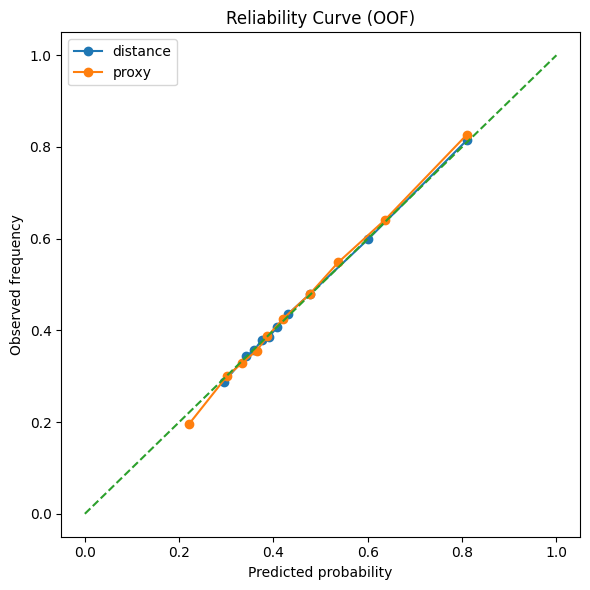

<Figure size 600x600 with 0 Axes>

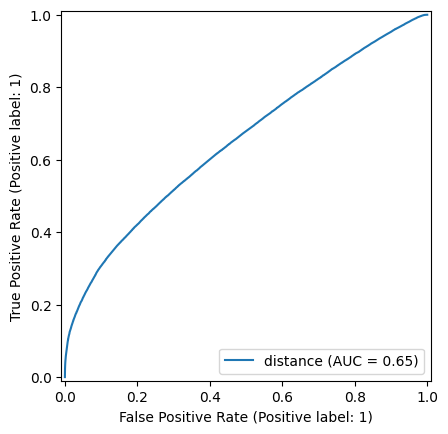

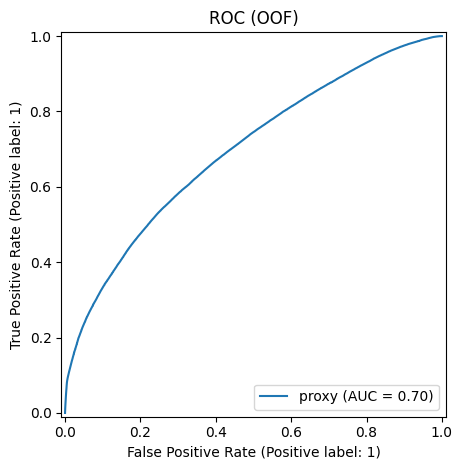

In [7]:

from sklearn.calibration import calibration_curve

# Calibration
plt.figure(figsize=(6,6))
for name, s in setups.items():
    prob_true, prob_pred = calibration_curve(y, s["oof"], n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Reliability Curve (OOF)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.tight_layout()
plt.show()

# ROC
plt.figure(figsize=(6,6))
for name, s in setups.items():
    RocCurveDisplay.from_predictions(y, s["oof"], name=name)
plt.title("ROC (OOF)")
plt.tight_layout()
plt.show()



## 8) Threshold Sweep: Is 0.5 the Best Cutoff?

**Why this matters:** Accuracy depends on the classification threshold. With shots (~45% makes), a threshold different from **0.5** might yield higher accuracy or F1.  
We sweep thresholds from **0.00 → 1.00** and record **Accuracy** and **F1** for each model.


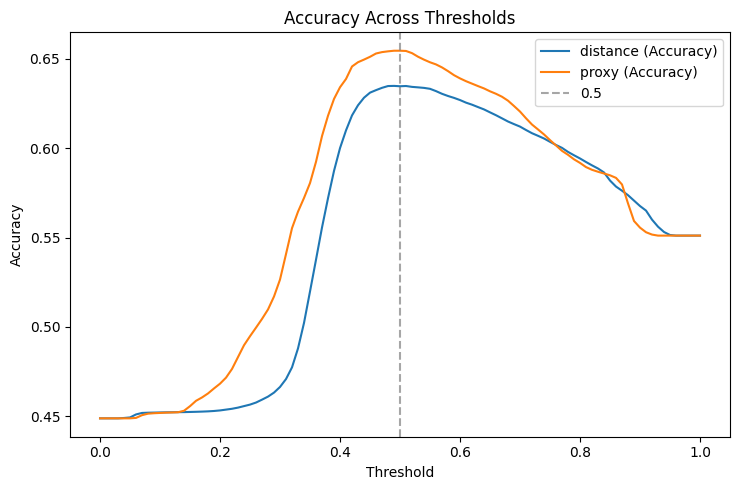

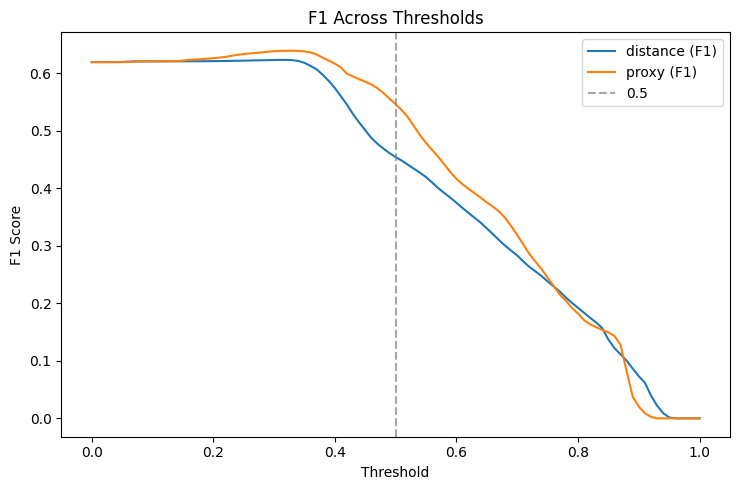

Best threshold per model (by Accuracy):


,setup,threshold,accuracy,f1
49,distance,0.49,0.634746,0.461320
151,proxy,0.50,0.654410,0.546478


In [8]:

thresholds = np.linspace(0.0, 1.0, 101)  # 0.00, 0.01, ..., 1.00
sweep_rows = []

for name, s in setups.items():
    probs = s["oof"]
    for t in thresholds:
        preds = (probs >= t).astype(int)
        acc = accuracy_score(y, preds)
        f1  = f1_score(y, preds)
        sweep_rows.append({"setup": name, "threshold": t, "accuracy": acc, "f1": f1})

sweep_df = pd.DataFrame(sweep_rows)

# Plot accuracy curves
plt.figure(figsize=(7.5,5))
for name in sweep_df["setup"].unique():
    sub = sweep_df[sweep_df["setup"]==name]
    plt.plot(sub["threshold"], sub["accuracy"], label=f"{name} (Accuracy)")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="0.5")
plt.title("Accuracy Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot F1 curves
plt.figure(figsize=(7.5,5))
for name in sweep_df["setup"].unique():
    sub = sweep_df[sweep_df["setup"]==name]
    plt.plot(sub["threshold"], sub["f1"], label=f"{name} (F1)")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="0.5")
plt.title("F1 Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

best_by_acc = sweep_df.loc[sweep_df.groupby("setup")["accuracy"].idxmax(), ["setup","threshold","accuracy","f1"]]
print("Best threshold per model (by Accuracy):")
display(best_by_acc)



## 9) Save Results

We save the metrics table so you can track results over time (or across seasons).


In [9]:

out_csv = "model_comparison_2014_distance_vs_proxy_with_accuracy.csv"
results.to_csv(out_csv, index=False)
out_csv


'model_comparison_2014_distance_vs_proxy_with_accuracy.csv'


## 10) Story‑Like Summary (What This Means on the Court)

Below we translate the numbers into a coach’s-eye take: who’s reading the game better, and what the right “cutoff” feels like when deciding if a shot is likely to drop.


In [10]:

# Pull the final metrics and the best threshold table if available
from textwrap import indent

print("=== Final Metrics (AUC, LogLoss, Brier, Accuracy@0.5) ===")
display(results)

# Try to fetch best thresholds table if created
try:
    display(best_by_acc)
except NameError:
    pass

# Build story text
lines = []
if set(["distance","proxy"]).issubset(results["setup"]):
    dist = results.set_index("setup").loc["distance"]
    prox = results.set_index("setup").loc["proxy"]

    # AUC
    lines.append(f"- **Separation (AUC)**: Proxy = {prox['AUC']:.3f}, Distance = {dist['AUC']:.3f}.")
    if prox['AUC'] - dist['AUC'] >= 0.02:
        lines.append("  → The proxy model **separates makes from misses noticeably better**. It’s picking up useful context—late-clock pressure and contest type—that raw distance alone misses.")
    elif prox['AUC'] > dist['AUC']:
        lines.append("  → The proxy model **edges out** distance on separation.")
    else:
        lines.append("  → Distance holds the edge on separation.")

    # LogLoss & Brier
    lines.append(f"- **Probability quality**: Proxy LogLoss = {prox['LogLoss']:.3f} vs Distance = {dist['LogLoss']:.3f}; Proxy Brier = {prox['Brier']:.3f} vs Distance = {dist['Brier']:.3f}.")
    if prox['LogLoss'] <= dist['LogLoss'] and prox['Brier'] <= dist['Brier']:
        lines.append("  → The proxy model’s probabilities are **slightly sharper and better calibrated**.")
    else:
        lines.append("  → Probability quality is mixed; check calibration curves.")

    # Accuracy
    lines.append(f"- **Accuracy @ 0.5**: Proxy = {prox['Accuracy']:.3f}, Distance = {dist['Accuracy']:.3f}.")
    if prox['Accuracy'] - dist['Accuracy'] >= 0.01:
        lines.append("  → At the standard 0.5 cutoff, Proxy **gets more shots right**.")
    elif prox['Accuracy'] > dist['Accuracy']:
        lines.append("  → Accuracy is basically a tie, Proxy a hair better.")
    else:
        lines.append("  → Distance slightly edges accuracy at 0.5.")

# Threshold story
try:
    for _, row in best_by_acc.iterrows():
        lines.append(f"- **Best threshold for {row['setup']} by Accuracy** is ~{row['threshold']:.2f} (Accuracy {row['accuracy']:.3f}, F1 {row['f1']:.3f}).")
    lines.append("  → Translation: if you cared only about getting the most calls right, you’d set the slider near those best thresholds rather than exactly at 0.5.")
except Exception:
    pass

print("\n".join(lines) if lines else "Run both models to generate a narrative.")


=== Final Metrics (AUC, LogLoss, Brier, Accuracy@0.5) ===


,setup,AUC,LogLoss,Brier,Accuracy
1,proxy,0.696277,0.619678,0.215859,0.654410
0,distance,0.651039,0.637735,0.224365,0.634546


,setup,threshold,accuracy,f1
49,distance,0.49,0.634746,0.461320
151,proxy,0.50,0.654410,0.546478


- **Separation (AUC)**: Proxy = 0.696, Distance = 0.651.
  → The proxy model **separates makes from misses noticeably better**. It’s picking up useful context—late-clock pressure and contest type—that raw distance alone misses.
- **Probability quality**: Proxy LogLoss = 0.620 vs Distance = 0.638; Proxy Brier = 0.216 vs Distance = 0.224.
  → The proxy model’s probabilities are **slightly sharper and better calibrated**.
- **Accuracy @ 0.5**: Proxy = 0.654, Distance = 0.635.
  → At the standard 0.5 cutoff, Proxy **gets more shots right**.
- **Best threshold for distance by Accuracy** is ~0.49 (Accuracy 0.635, F1 0.461).
- **Best threshold for proxy by Accuracy** is ~0.50 (Accuracy 0.654, F1 0.546).
  → Translation: if you cared only about getting the most calls right, you’d set the slider near those best thresholds rather than exactly at 0.5.
